In [1]:
from pathlib import Path

%pip install --quiet --disable-pip-version-check numpy==2.5.3
%pip install --quiet --disable-pip-version-check pandas==3.0.6
%pip install --quiet --disable-pip-version-check matplotlib==3.11.2

import io
import re
import zipfile
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib.ticker import StrMethodFormatter

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
OUTPUT = Path("results/equal_weights")
TITLE = "Equal-weight factor portfolio"
SOURCE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
START = "2003-01"
END = "2026-08"
COST_BPS = 10
INITIAL_VALUE = 10000
FACTORS = ["Value", "Profitability", "Momentum"]
ASSETS = FACTORS + ["EM market", "Cash"]
DATA = Path("data")
DATA.mkdir(exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

In [3]:
def load_monthly(filename):
    path = DATA / filename
    if not path.exists():
        with urlopen(SOURCE + filename, timeout=30) as response:
            path.write_bytes(response.read())
    with zipfile.ZipFile(path) as archive:
        member = next(name for name in archive.namelist() if name.lower().endswith(".csv"))
        lines = archive.read(member).decode("utf-8-sig").splitlines()
    first = next(i for i, line in enumerate(lines) if re.match(r"^\s*\d{6}\s*,", line))
    last = first
    while last < len(lines) and re.match(r"^\s*\d{6}\s*,", lines[last]):
        last += 1
    frame = pd.read_csv(io.StringIO("\n".join(lines[first - 1:last])), index_col=0)
    frame.columns = frame.columns.str.strip()
    frame.index = pd.to_datetime(frame.index.astype(str).str.strip(), format="%Y%m") + pd.offsets.MonthEnd(0)
    frame.index.name = "Month"
    if not frame.index.is_unique or not frame.index.is_monotonic_increasing:
        raise ValueError("The source dates must be unique and ordered.")
    return frame.apply(pd.to_numeric).replace([-99.99, -999], np.nan) / 100

In [4]:
raw = load_monthly("Emerging_5_Factors_CSV.zip")
momentum = load_monthly("Emerging_MOM_Factor_CSV.zip")
data = raw[["HML", "RMW", "RF"]].copy()
data["WML"] = momentum["WML"]
files = {
    "Value": ("Emerging_Markets_6_Portfolios_ME_BE-ME_CSV.zip", ["SMALL HiBM", "BIG HiBM"]),
    "Profitability": ("Emerging_Markets_6_Portfolios_ME_OP_CSV.zip", ["SMALL HiOP", "BIG HiOP"]),
    "Momentum": ("Emerging_Markets_6_Portfolios_ME_Prior_12_2_CSV.zip", ["SMALL HiPRIOR", "BIG HiPRIOR"]),
}
for factor, (filename, columns) in files.items():
    data[factor] = load_monthly(filename)[columns].mean(axis=1, skipna=False)
data["EM market"] = raw["Mkt-RF"] + raw["RF"]
data["Cash"] = raw["RF"]
data = data.loc[:END]
data = data.loc[data.dropna().index.min():]
if not np.isfinite(data.to_numpy()).all() or (data[ASSETS] <= -1).any().any():
    raise ValueError("The monthly returns contain missing or invalid values.")
if not data.index.to_period("M").equals(pd.period_range(data.index[0], data.index[-1], freq="M")):
    raise ValueError("The monthly history has gaps.")
dates = data.loc[START:END].index
display((data.loc[dates, ASSETS].tail(6) * 100).round(2).rename_axis("Monthly returns (%)"))
display(pd.Series({
    "Source": "Kenneth French emerging-market monthly portfolios",
    "Period": f"{dates[0]:%b %Y} to {dates[-1]:%b %Y}",
    "Factor portfolios": "Average of small and big high-value, high-profitability or winner portfolios",
    "Rebalancing": "Monthly",
    "Trading cost": f"{COST_BPS} basis points on equity purchases and sales",
    "Cash return": "U.S. one-month T-bill proxy from the source",
    "Data limits": "Current historical series; revisions and trading within the source portfolios are not reconstructed",
}, name="Setup").to_frame())

,Value,Profitability,Momentum,EM market,Cash
Monthly returns (%),,,,,
2026-03-31,-10.94,-10.88,-13.28,-12.07,0.29
2026-04-30,9.07,13.18,19.10,13.92,0.29
2026-05-31,1.88,4.78,7.78,7.75,0.31
2026-06-30,-2.26,-1.01,-3.47,-1.69,0.29
2026-07-31,0.88,-3.58,-13.03,-3.89,0.33
2026-08-31,5.46,5.19,10.69,4.66,0.29


,Setup
Source,Kenneth French emerging-market monthly portfolios
Period,Jan 2003 to Aug 2026
Factor portfolios,"Average of small and big high-value, high-prof..."
Rebalancing,Monthly
Trading cost,10 basis points on equity purchases and sales
Cash return,U.S. one-month T-bill proxy from the source
Data limits,Current historical series; revisions and tradi...


In [5]:
def backtest(targets, cost_bps=COST_BPS):
    rows = []
    previous = np.array([0.0, 0.0, 0.0, 0.0, 1.0])
    for date, row in targets.iterrows():
        target = row[ASSETS].to_numpy(dtype=float)
        if not np.isfinite(target).all() or (target < 0).any() or not np.isclose(target.sum(), 1):
            raise ValueError("Portfolio weights must be positive and add up to one.")
        returns = data.loc[date, ASSETS].to_numpy()
        traded = np.abs(target[:-1] - previous[:-1]).sum()
        gross = float(target @ returns)
        cost = float(traded * cost_bps / 10000)
        rows.append({"Month": date, "Gross return": gross, "Net return": (1 - cost) * (1 + gross) - 1,
                     "Traded value": traded, "Cash weight": target[-1]})
        previous = target * (1 + returns) / (1 + gross)
    return pd.DataFrame(rows).set_index("Month")

In [6]:
def summarize(results):
    rows = []
    for name, sample in results.items():
        returns = sample["Net return"]
        wealth = (1 + returns).cumprod()
        peaks = np.maximum.accumulate(np.r_[1.0, wealth.to_numpy()])[1:]
        excess = returns - data.loc[returns.index, "RF"]
        rows.append({
            "Strategy": name,
            "Gross annual return %": ((1 + sample["Gross return"]).prod() ** (12 / len(sample)) - 1) * 100,
            "Net annual return %": (wealth.iloc[-1] ** (12 / len(sample)) - 1) * 100,
            "Volatility %": returns.std(ddof=1) * np.sqrt(12) * 100,
            "Sharpe ratio": excess.mean() / excess.std(ddof=1) * np.sqrt(12),
            "Max drawdown %": (wealth.to_numpy() / peaks - 1).min() * 100,
            "Annual traded value %": sample["Traded value"].mean() * 12 * 100,
            "Average cash %": sample["Cash weight"].mean() * 100,
        })
    return pd.DataFrame(rows).set_index("Strategy")

In [7]:
equal = pd.DataFrame([np.r_[np.full(3, 1 / 3), 0, 0]] * len(dates), index=dates, columns=ASSETS)
market = equal * 0
market["EM market"] = 1
strategies = {"Equal weights": equal, "EM market": market}

In [8]:
results = {name: backtest(targets) for name, targets in strategies.items()}
performance = summarize(results)
display(performance.round(3))

,Gross annual return %,Net annual return %,Volatility %,Sharpe ratio,Max drawdown %,Annual traded value %,Average cash %
Strategy,,,,,,,
Equal weights,14.355,14.340,19.292,0.711,-61.838,12.538,0.0
EM market,11.396,11.391,19.633,0.567,-61.203,4.225,0.0


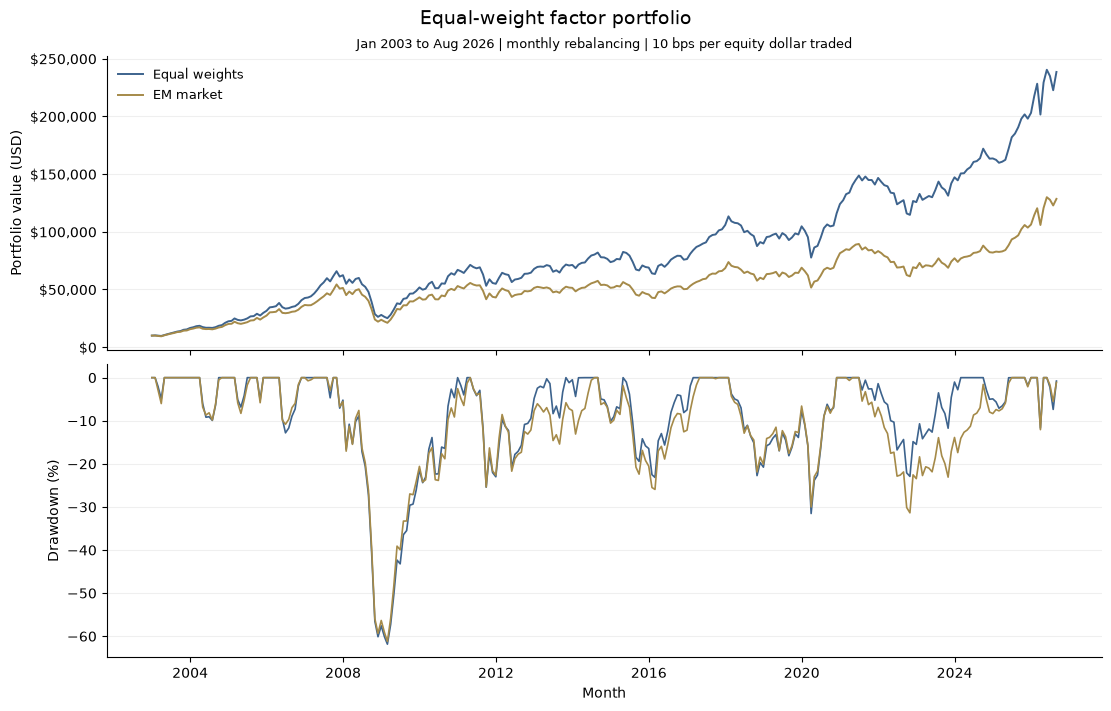

In [9]:
palette = ["#3d638d", "#a58a49", "#28745e", "#bb6847", "#80629e"]
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout="constrained")
for (name, result), color in zip(results.items(), palette):
    wealth = (1 + result["Net return"]).cumprod()
    initial_date = wealth.index[0] - pd.offsets.MonthEnd(1)
    wealth = pd.concat([pd.Series([1.0], index=[initial_date]), wealth])
    axes[0].plot(wealth.index, wealth * INITIAL_VALUE, label=name, color=color, linewidth=1.4)
    axes[1].plot(wealth.index, (wealth / wealth.cummax() - 1) * 100, color=color, linewidth=1.2)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[0].legend(frameon=False, loc="upper left", fontsize=9)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Month")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
fig.suptitle(TITLE, fontsize=14)
axes[0].set_title(f"{dates[0]:%b %Y} to {dates[-1]:%b %Y} | monthly rebalancing | {COST_BPS} bps per equity dollar traded", fontsize=9)
fig.savefig(OUTPUT / "performance.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
data.to_csv(OUTPUT / "monthly_inputs.csv", date_format="%Y-%m-%d")
performance.to_csv(OUTPUT / "performance.csv")
pd.concat(results, names=["Strategy", "Month"]).to_csv(OUTPUT / "portfolio_returns.csv", date_format="%Y-%m-%d")
pd.concat(strategies, names=["Strategy", "Month"]).to_csv(OUTPUT / "allocations.csv", date_format="%Y-%m-%d")

We split the portfolio equally between Value, Profitability and Momentum and reset the weights each month. From January 2003 to August 2026, it returned 14.34% a year after the assumed trading costs, compared with 11.39% for the EM market comparison. Its largest fall from a previous peak was 61.84%. This gives us a useful starting point for judging the extra models. It also shows how much risk can remain when we spread money across three factors. These are research portfolio series; the cost estimate covers our allocation trades, not all trading inside those portfolios.